In [1]:
from typing import List, Optional, Tuple

import hydra
import torch
import pytorch_lightning as pl
from omegaconf import DictConfig
from pytorch_lightning import Callback, LightningDataModule, LightningModule, Trainer
from pytorch_lightning.loggers import LightningLoggerBase
from models.module import PatchClassificationModule
from models.model import construct_PPNet
from models.push import push_prototypes
import json
import random
import netCDF4
import matplotlib.pyplot as plt
import numpy as np
import os
import cv2
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import wasserstein_distance

import warnings
#from skimage.measure import compare_ssim
from skimage.transform import resize
from PIL import Image

import numpy as np
from scipy.spatial.distance import cdist
from ot import emd2  # Wasserstein distance squared


/home/ines/televit_xai/xai/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load data

In [2]:
input_vars = [
    'lst_day',
    'ndvi',
    'rel_hum',
    'ssrd',
    'sst',
    't2m_min',
    'tp',
    'vpd']

# use only 1 year
path = "/data/ines/positive_batches/test/"

#extract mean for normalisation
path_mean = "/data/ines/positive_batches/train/mean_std.json"
with open(path_mean, 'r') as json_file:
    mean_std_dict = json.load(json_file)


batch_files = [filename for filename in os.listdir(path) if filename.startswith('batch')]



In [3]:
#extract the model 
last_checkpoint = os.path.join('/home/ines/televit_xai/results/final/push_best.pth')

if os.path.exists(last_checkpoint):
    ppnet = torch.load(last_checkpoint)
    ppnet = ppnet.cuda()

print(len(ppnet.prototype_vectors))


/tmp/ipykernel_3764421/2451248402.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ppnet = torch.load(last_checkpoint)


20


In [4]:
def get_image_gt(file):
        '''
        Function that configure the input to the format required by ppnet
        '''
        inputs = []
        dataset = netCDF4.Dataset(path  + file, mode='r') 
        #dataset = netCDF4.Dataset("/data/ines/positive_batches/test/batch_0_1277.nc")
        for variable_name in input_vars:

            variable_data = dataset.variables[variable_name][:][0]

            variable_data  = (variable_data  - mean_std_dict[f'{variable_name}_mean'])/mean_std_dict[f'{variable_name}_std']
            variable_data = np.nan_to_num(variable_data, nan=-1)

            input = torch.tensor(variable_data)
            inputs.append(input)

        ground_truth = dataset.variables["gwis_ba"][:][0] 
        mask_nan = np.isnan(ground_truth)
        ground_truth = np.nan_to_num(ground_truth, nan=0)

        ground_truth = np.where(ground_truth != 0, 1, 0)
        ground_truth = np.where(mask_nan, np.nan, np.where(ground_truth!= 0, 1, 0))
        ground_truth = np.ma.masked_invalid(ground_truth)


        inputs_tensor = torch.stack(inputs)  # Stack the tensors in the list
        image = inputs_tensor.numpy()
        inputs_tensor = inputs_tensor.unsqueeze(0).cuda()

        return inputs_tensor, image, ground_truth


def get_similarity_pred(inputs_tensor, prototype_number):
        '''
        Get the prediction and activation map for a specific prototype
        '''
        conv_features = ppnet.conv_features(inputs_tensor)
        logits, distance = ppnet.forward_from_conv_features(conv_features)

        logits = logits.permute(0, 3, 1, 2)
        logits = logits[0]

        pred = torch.argmax(logits, dim=0).cpu().detach().numpy()

        proto_dist_img_j = distance[0][prototype_number, :, :].cpu().detach().numpy()
        proto_act_img_j = (2-proto_dist_img_j)/2

        return pred, proto_act_img_j



def plot_input_heatmap(image,proto_act_img_j):
        cols = 4
        rows = 2
        fig, axs = plt.subplots(rows, cols+1, figsize=(16, 8)) 
        for channel in range(len(input_vars)):
            row_idx = channel // cols
            col_idx = channel % cols

            im = axs[row_idx, col_idx].imshow(rescale_image(image[ channel, :, :]), cmap = "gray")

            axs[row_idx, col_idx].set_title(f"Channel {input_vars[channel]}")
            plt.colorbar(im, ax=axs[row_idx, col_idx], fraction=0.046, pad=0.04)
            axs[row_idx, col_idx].axis('off')


        im = axs[0,-1].imshow(rescale_image(proto_act_img_j),cmap = "gray")
        plt.colorbar(im, ax = axs[0,-1], fraction=0.046, pad=0.04)
        axs[0,-1].axis('off')
        axs[1,-1].axis('off')
        plt.tight_layout()

       



In [20]:
# get confidence interval
pourcentage_fire_pixel = []
i = 0
for file in batch_files:
    inputs_tensor, image, ground_truth = get_image_gt(file)
    pourcentage_fire_pixel.append(ground_truth.sum()/(128*128))
    if ground_truth.sum()/(128*128) >0.02:
        i+=1

In [21]:
print((pourcentage_fire_pixel> np.percentile(pourcentage_fire_pixel, 85)).sum())
print(np.percentile(pourcentage_fire_pixel, 85)*100)
print(np.percentile(pourcentage_fire_pixel, 85)*128*128)

3020
2.83203125
464.0


637


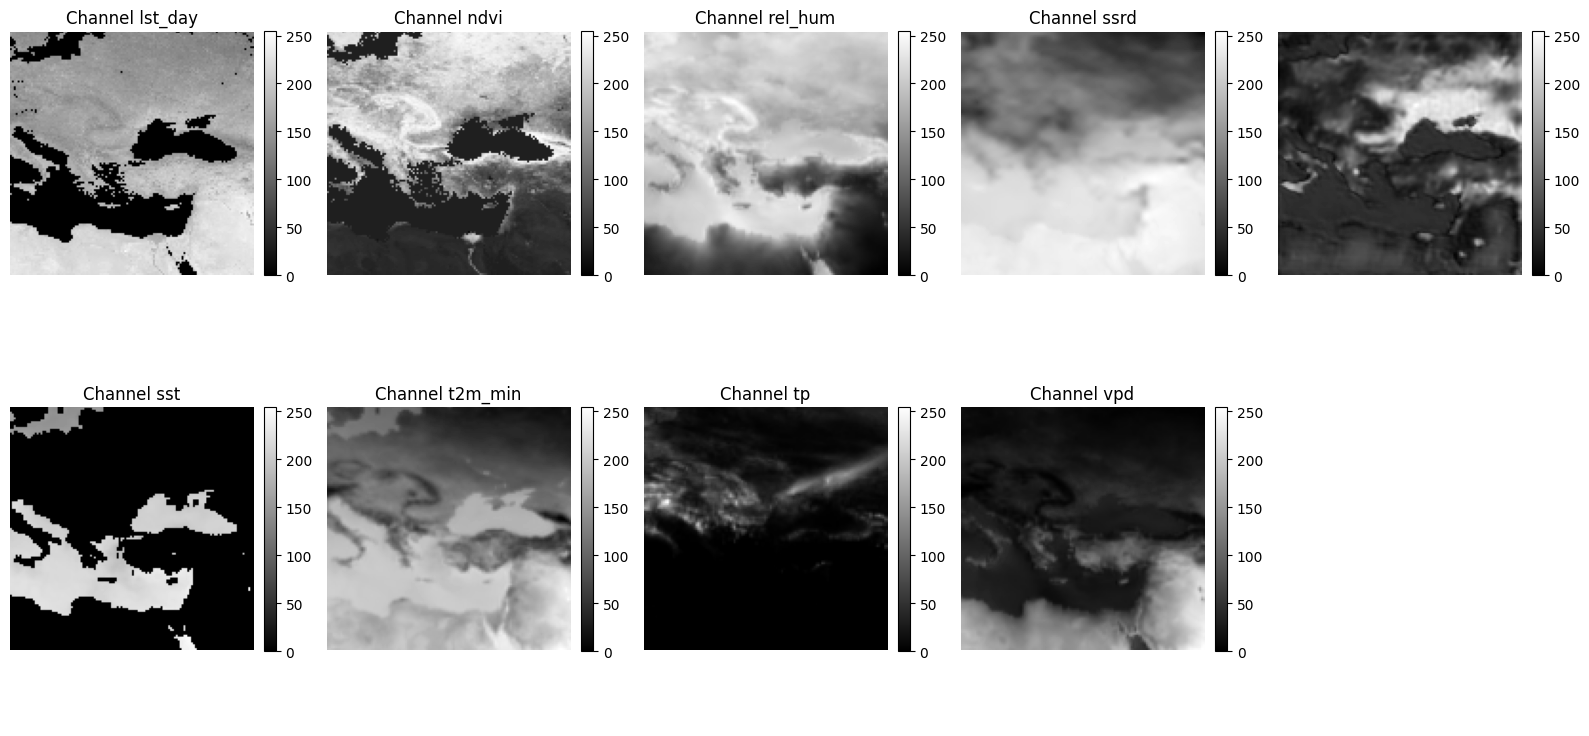

In [19]:
random_files = random.sample(batch_files, min(1, len(batch_files)))
world = [batch_files[0],batch_files[44],batch_files[91],batch_files[93],batch_files[107],batch_files[155],batch_files[181], batch_files[225]]

for file in [batch_files[225]]:
    inputs_tensor, image, ground_truth = get_image_gt(file)

    pred,proto_act_img_j = get_similarity_pred(inputs_tensor, 12)
    print((pred==1).sum())
    plot_input_heatmap(image,proto_act_img_j)




# wasserstein distance

In [5]:

def rescale_image(img):
  min = np.min(img)
  max = np.max(img)

  img_scaled = (img - min) / (max - min) * 255
  img_scaled = np.clip(img_scaled, 0, 255).astype(np.uint8)
  return img_scaled

def get_img(img, norm_exposure=False):
  '''
  Prepare an image for image processing tasks
  '''
  # flatten returns a 2d grayscale arr
  # resizing returns float vals 0:255; convert to ints for downstream tasks
  if norm_exposure:
    img = normalize_exposure(img)
  return img


def get_histogram(img):
  '''
  Get the histogram of an image. For an 8-bit, grayscale image, the
  histogram will be a 256 unit vector in which the nth value indicates
  the percent of the pixels in the image with the given darkness level.
  The histogram's values sum to 1.
  '''
  h, w = img.shape
  hist = [0.0] * 256
  for i in range(h):
    for j in range(w):
      hist[img[i, j]] += 1
  return np.array(hist) / (h * w) 


def normalize_exposure(img):
  '''
  Normalize the exposure of an image.
  '''
  img = img.astype(int)
  hist = get_histogram(img)

  # get the sum of vals accumulated by each position in hist
  cdf = np.array([sum(hist[:i+1]) for i in range(len(hist))])
  
  # determine the normalization values for each unit of the cdf
  sk = np.uint8(255 * cdf)
  # normalize each position in the output image
  height, width = img.shape
  normalized = np.zeros_like(img)
  for i in range(0, height):
    for j in range(0, width):
      normalized[i, j] = sk[img[i, j]]
  return normalized.astype(int)



def earth_movers_distance(path_a, path_b):
  '''
  Measure the Earth Mover's distance between two images
  @args:
    {str} path_a: the path to an image file
    {str} path_b: the path to an image file
  @returns:
    TODO
  '''
  img_a = get_img(path_a, norm_exposure=True)
  img_b = get_img(path_b, norm_exposure=True)
  hist_a = get_histogram(img_a)
  hist_b = get_histogram(img_b)
  return wasserstein_distance(hist_a, hist_b)


def plot_hist_EMD(res):
    cols = 4
    rows = 2
    fig, axs = plt.subplots(rows, cols, figsize=(16, 8))  # Create subplots (2x4 grid)

    # Initialize variables to track global x and y limits
    global_min_x = float('inf')
    global_max_x = float('-inf')
    global_min_y = float('inf')
    global_max_y = float('-inf')

    # Loop through each channel and plot the histograms
    for channel in range(len(input_vars)):
        row_idx = channel // cols
        col_idx = channel % cols

        coef_chanel = res[channel]

        # Calculate histogram data for the current channel
        counts, bin_edges = np.histogram(coef_chanel, bins=100)

        # Update global x and y limits based on the current histogram data
        global_min_x = min(global_min_x, bin_edges.min())
        global_max_x = max(global_max_x, bin_edges.max())
        global_min_y = min(global_min_y, counts.min())
        global_max_y = max(global_max_y, counts.max())

        # Plot the histogram
        axs[row_idx, col_idx].hist(coef_chanel, bins=100)
        axs[row_idx, col_idx].set_title(f"Channel {input_vars[channel]}")

    # After all histograms are plotted, set the same x and y limits for all subplots
    for ax in axs.flat:
        ax.set_xlim(global_min_x, global_max_x)  # Set the same x limits for all subplots
        ax.set_ylim(global_min_y, global_max_y)  # Set the same y limits for all subplots

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()
    plt.show()




In [ ]:
save_path = 'EMD_protopush_19.npy'

# Check if file exists to resume from it
if os.path.exists(save_path):
    print(f"Loading saved data from {save_path}")
    res = np.load(save_path, allow_pickle=True).tolist()
else:
    res = [[] for _ in range(8)]  # If no saved file, start fresh

for idx, file in enumerate(batch_files[561:]):
    try:
        inputs_tensor, image, ground_truth = get_image_gt(file)

        if ground_truth.sum() / (128 * 128) > 0.02:
            for i in range(8):
                pred, proto_act_img_j = get_similarity_pred(inputs_tensor, 19)

                img_b = proto_act_img_j
                img_a = image[i, :, :]

                img_a_scaled = rescale_image(img_a)
                img_b_scaled = rescale_image(img_b)

                # Normalize heatmaps to make them valid distributions
                heatmap1 = img_a_scaled / np.sum(img_a_scaled)
                heatmap2 = img_b_scaled / np.sum(img_b_scaled)

                # Get spatial coordinates of the grids
                x_coords, y_coords = np.meshgrid(np.arange(heatmap1.shape[1]), np.arange(heatmap1.shape[0]))
                coords = np.stack([x_coords.ravel(), y_coords.ravel()], axis=-1)

                # Flatten the heatmaps
                weights1 = heatmap1.ravel()
                weights2 = heatmap2.ravel()

                # Compute the cost matrix (Euclidean distance between grid points)
                cost_matrix = cdist(coords, coords, metric='euclidean')

                # Compute the EMD (Wasserstein distance)
                emd_distance = emd2(weights1, weights2, cost_matrix)

                res[i].append(emd_distance)
        
            # Save after each file to avoid data loss
            np.save(save_path, res)
            nb =  561 + idx
            print(f"Progress saved after file {nb}")
    
    except Exception as e:
        print(f"Error processing file {file}: {e}")

# Plot final results
plot_hist_EMD(res)


Loading saved data from EMD_protopush_19.npy


/home/ines/televit_xai/xai/lib/python3.8/site-packages/ot/lp/__init__.py:630: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  check_result(result_code)


Progress saved after file 331
Progress saved after file 332
Progress saved after file 373
Progress saved after file 374
Progress saved after file 375
Progress saved after file 377
Progress saved after file 384
Progress saved after file 385
Progress saved after file 386
Progress saved after file 387
Progress saved after file 388
Progress saved after file 396
Progress saved after file 469
Progress saved after file 470
Progress saved after file 474
Progress saved after file 524
Progress saved after file 525
Progress saved after file 527
Progress saved after file 559
Progress saved after file 560


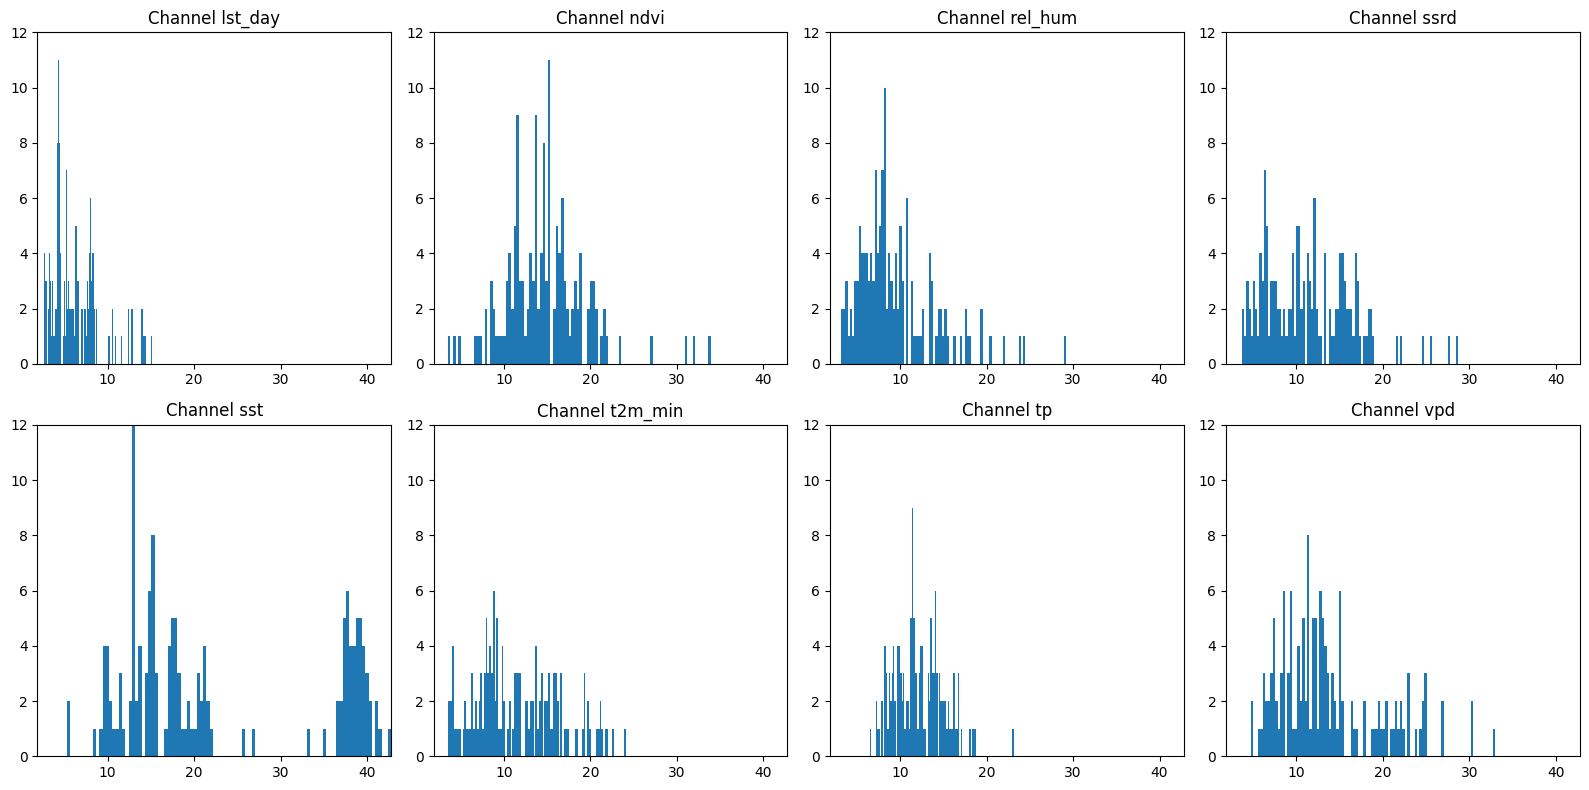

In [5]:
save_path = 'EMD_protopush_18.npy'


res = np.load(save_path, allow_pickle=True).tolist()
plot_hist_EMD(res)

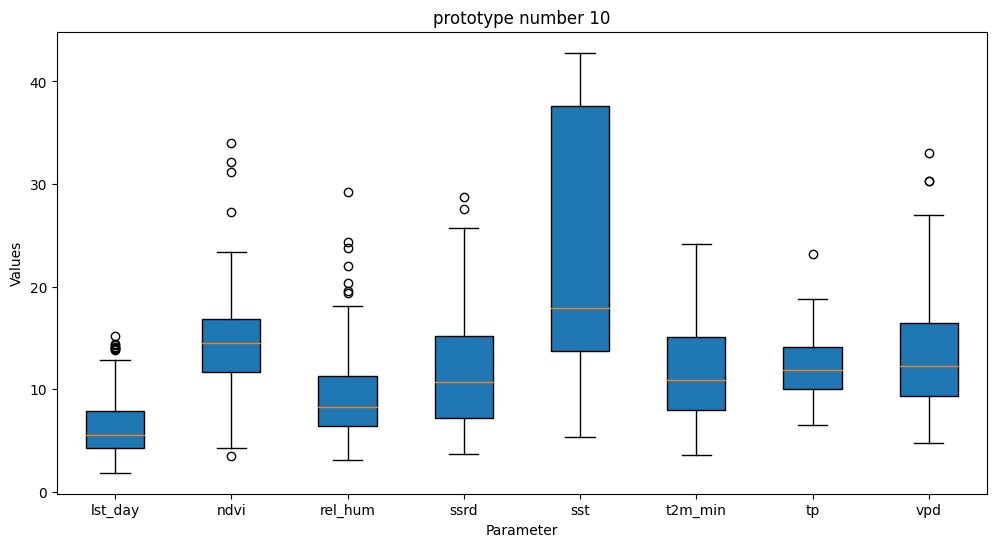

In [6]:

plt.figure(figsize=(12, 6))
plt.boxplot(res, vert=True, patch_artist=True, labels=[ input_vars[i] for i in range(8)])

plt.title(f"prototype number 10")
plt.xlabel("Parameter")
plt.ylabel("Values")
plt.show()


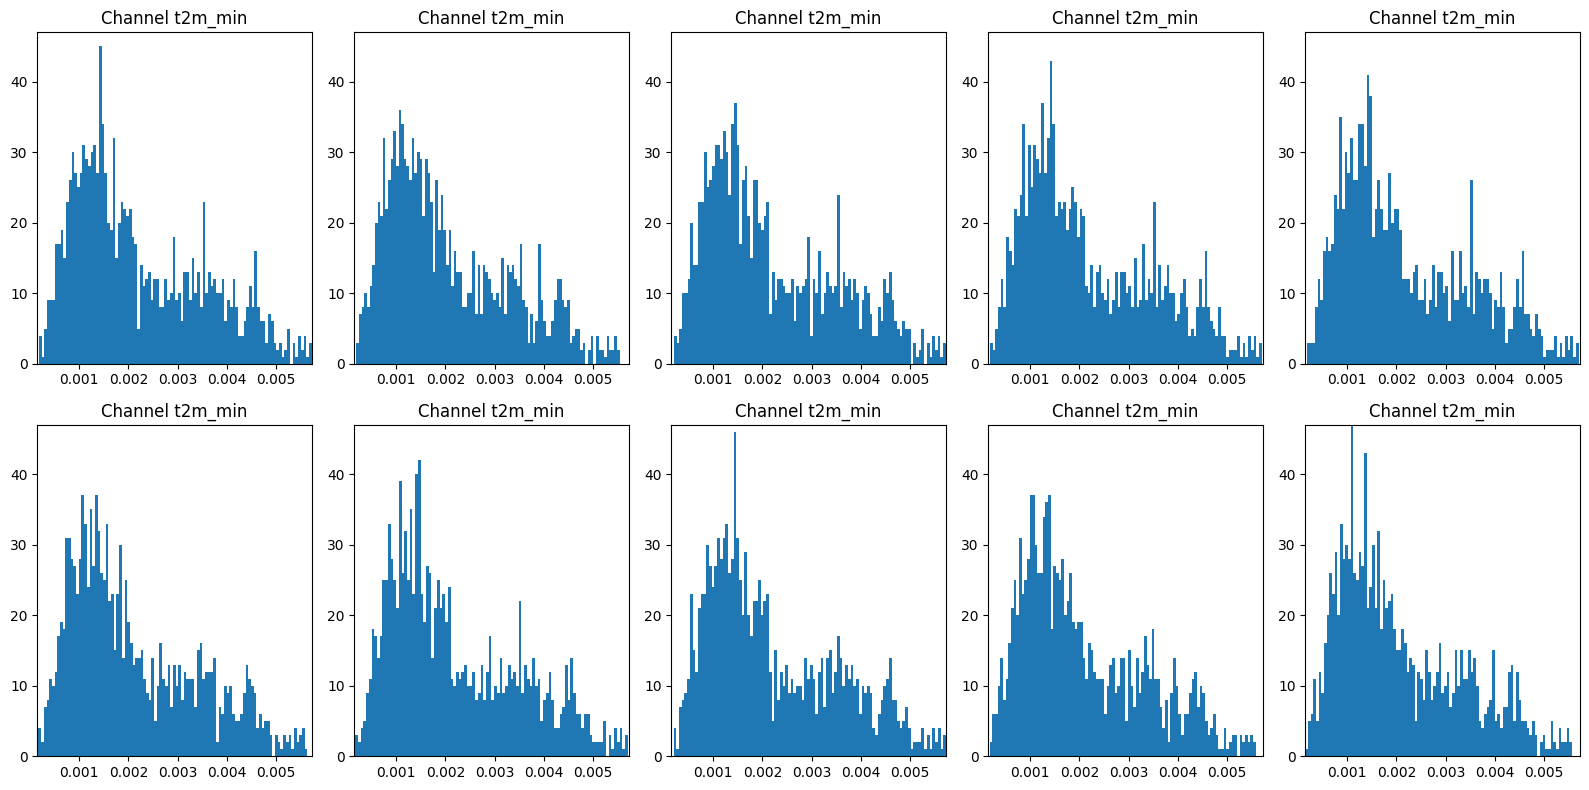

In [ ]:
def plot_chanel_proto_all(chanel_number):
    cols = 5
    rows = 2
    fig, axs = plt.subplots(rows, cols, figsize=(16, 8))  # Create subplots (2x4 grid)

    # Initialize variables to track global x and y limits
    global_min_x = float('inf')
    global_max_x = float('-inf')
    global_min_y = float('inf')
    global_max_y = float('-inf')

    # Loop through each channel and plot the histograms
    for i in range(10):
        row_idx = i // cols
        col_idx = i % cols

        coef_chanel = EM[i][chanel_number]

        # Calculate histogram data for the current channel
        counts, bin_edges = np.histogram(coef_chanel, bins=100)

        # Update global x and y limits based on the current histogram data
        global_min_x = min(global_min_x, bin_edges.min())
        global_max_x = max(global_max_x, bin_edges.max())
        global_min_y = min(global_min_y, counts.min())
        global_max_y = max(global_max_y, counts.max())

        # Plot the histogram
        axs[row_idx, col_idx].hist(coef_chanel, bins=100)
        axs[row_idx, col_idx].set_title(f"Channel {input_vars[chanel_number]}")

    # After all histograms are plotted, set the same x and y limits for all subplots
    for ax in axs.flat:
        ax.set_xlim(global_min_x, global_max_x)  # Set the same x limits for all subplots
        ax.set_ylim(global_min_y, global_max_y)  # Set the same y limits for all subplots

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()
    plt.show()


plot_chanel_proto_all(5)

In [29]:
EM = []
for i in range (10):
    proto = 10+i
    data = np.load(f'EM_proto/EMD_protonopush_{proto}.npy')
    EM.append(data)

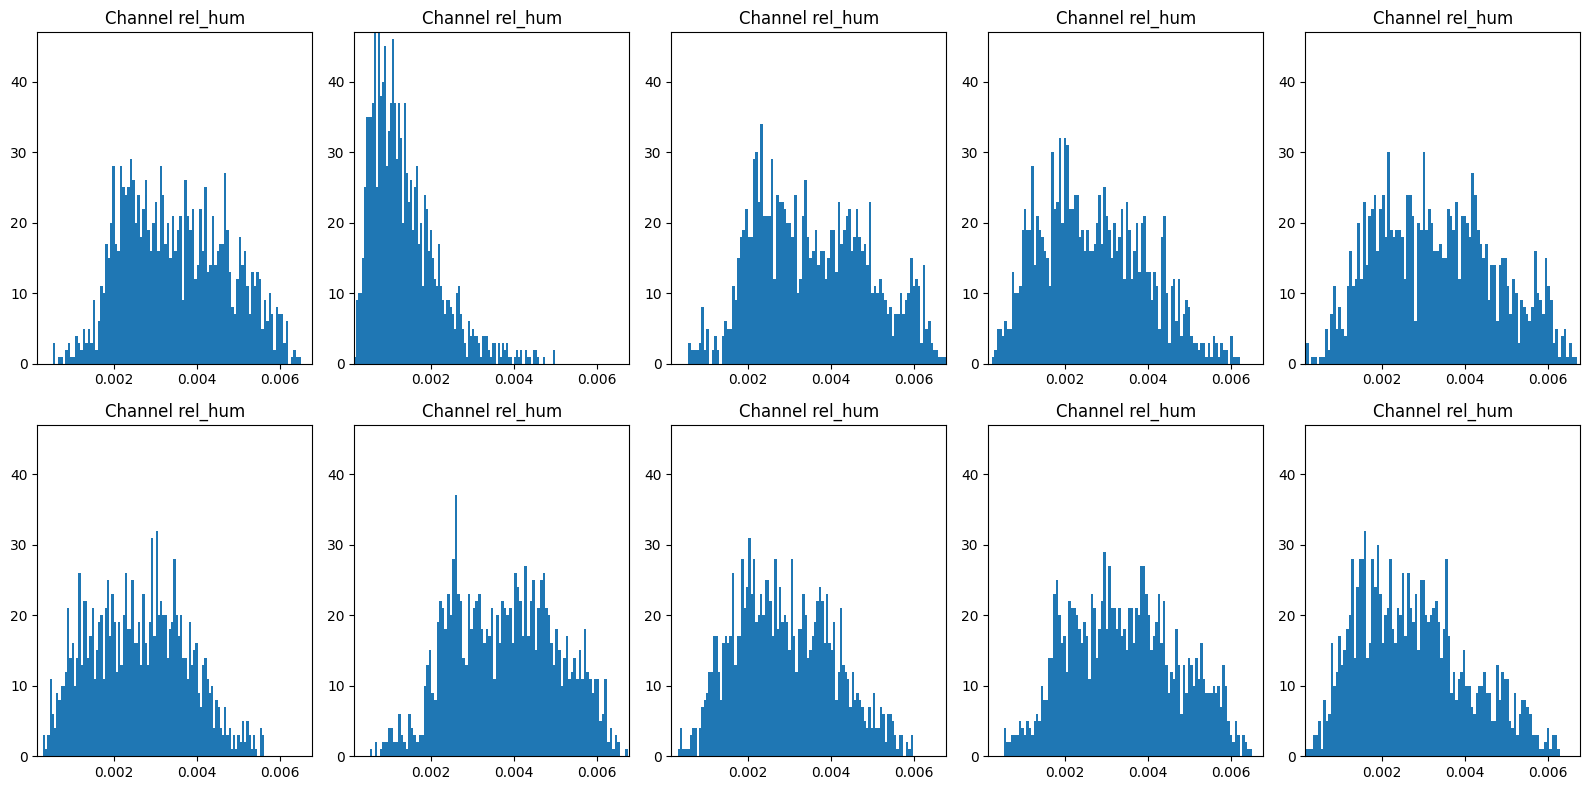

In [7]:
def plot_chanel_proto_all(chanel_number):
    cols = 5
    rows = 2
    fig, axs = plt.subplots(rows, cols, figsize=(16, 8))  # Create subplots (2x4 grid)

    # Initialize variables to track global x and y limits
    global_min_x = float('inf')
    global_max_x = float('-inf')
    global_min_y = float('inf')
    global_max_y = float('-inf')

    # Loop through each channel and plot the histograms
    for i in range(10):
        row_idx = i // cols
        col_idx = i % cols

        coef_chanel = EM[i][chanel_number]

        # Calculate histogram data for the current channel
        counts, bin_edges = np.histogram(coef_chanel, bins=100)

        # Update global x and y limits based on the current histogram data
        global_min_x = min(global_min_x, bin_edges.min())
        global_max_x = max(global_max_x, bin_edges.max())
        global_min_y = min(global_min_y, counts.min())
        global_max_y = max(global_max_y, counts.max())

        # Plot the histogram
        axs[row_idx, col_idx].hist(coef_chanel, bins=100)
        axs[row_idx, col_idx].set_title(f"Channel {input_vars[chanel_number]}")

    # After all histograms are plotted, set the same x and y limits for all subplots
    for ax in axs.flat:
        ax.set_xlim(global_min_x, global_max_x)  # Set the same x limits for all subplots
        ax.set_ylim(global_min_y, global_max_y)  # Set the same y limits for all subplots

    # Adjust layout to prevent overlapping labels
    plt.tight_layout()
    plt.show()


plot_chanel_proto_all(2)

In [8]:
EM[0].shape

(8, 1304)

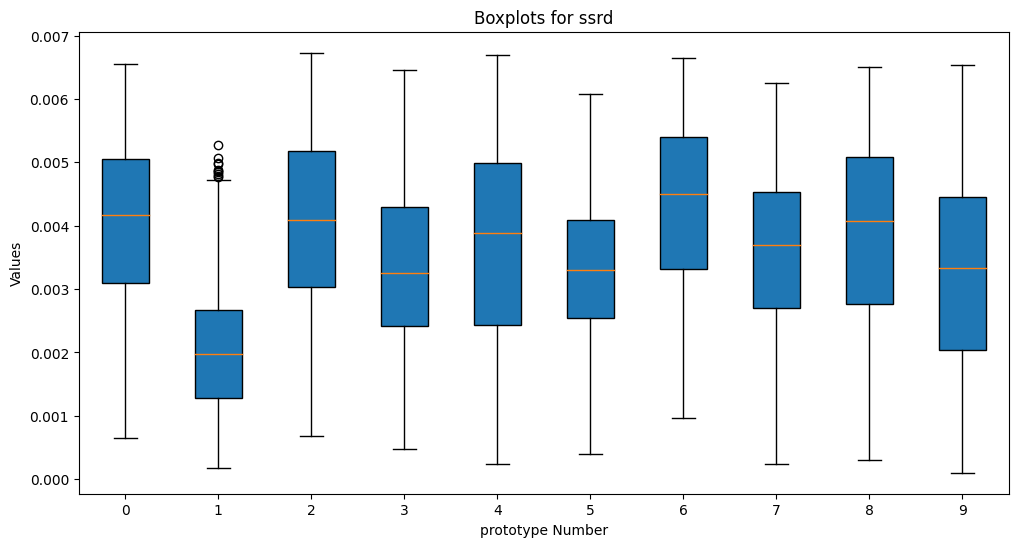

In [9]:


def plot_all_boxplots(proto_number):
    """
    Plots 8 boxplots (one for each row in the EM array) in a single graph.
    """

    plt.figure(figsize=(12, 6))
    plt.boxplot(EM[proto_number].T, vert=True, patch_artist=True, labels=[ input_vars[i] for i in range(EM[proto_number].shape[0])])
    
    plt.title(f"prototype number {proto_number}")
    plt.xlabel("Parameter")
    plt.ylabel("Values")
    plt.show()

def plot_all_proto(chanel_number):
    """
    Plots 8 boxplots (one for each row in the EM array) in a single graph.
    """


    data = [ EM[i][chanel_number] for i in range(len(EM))]

    plt.figure(figsize=(12, 6))
    plt.boxplot(np.array(data).T, vert=True, patch_artist=True, labels=[ i for i in range(len(np.array(data)))])
    
    plt.title(f"Boxplots for {input_vars[chanel_number]}")
    plt.xlabel("prototype Number")
    plt.ylabel("Values")
    plt.show()

# Call the function to plot all 8 boxplots
plot_all_proto(3)


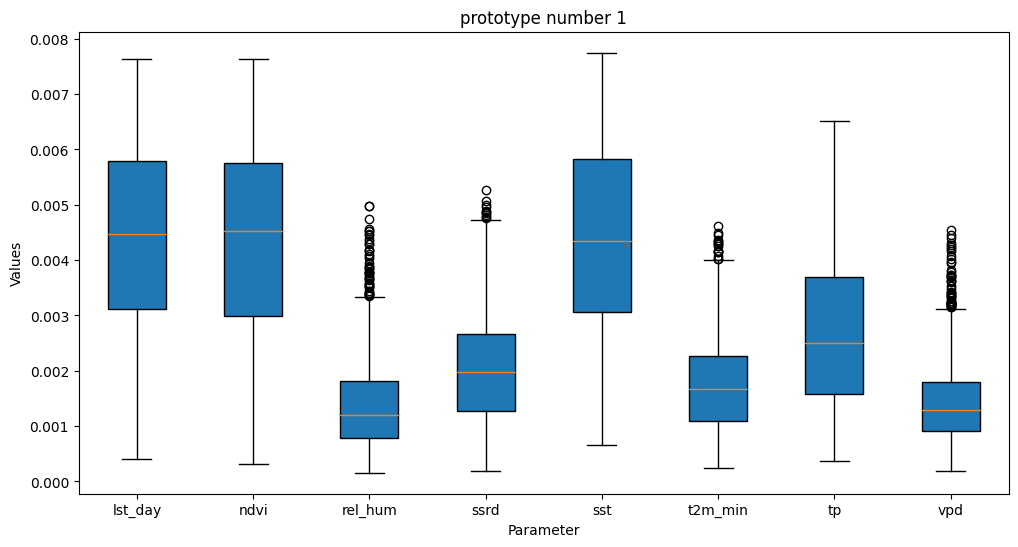

In [30]:
plot_all_boxplots(1)

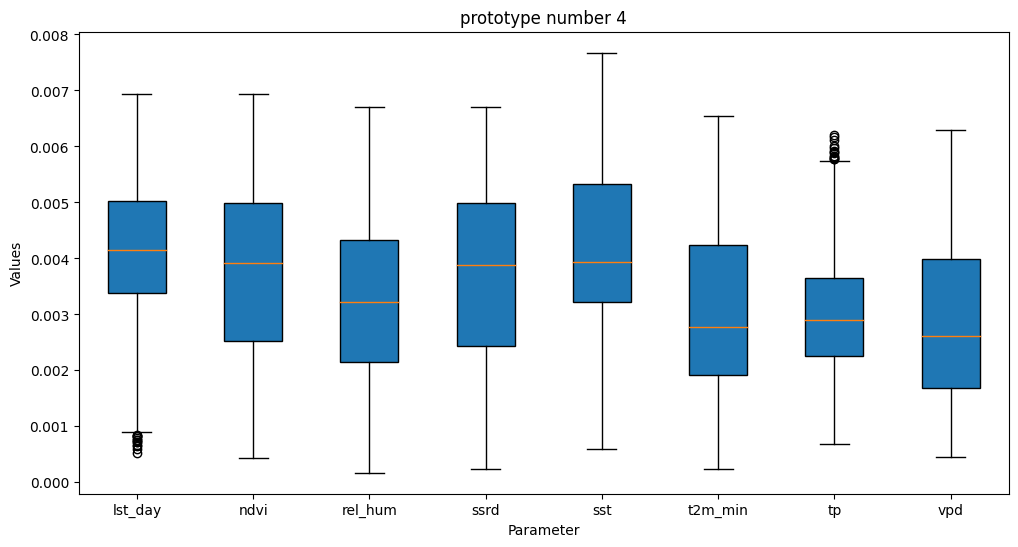

In [36]:
plot_all_boxplots(4)

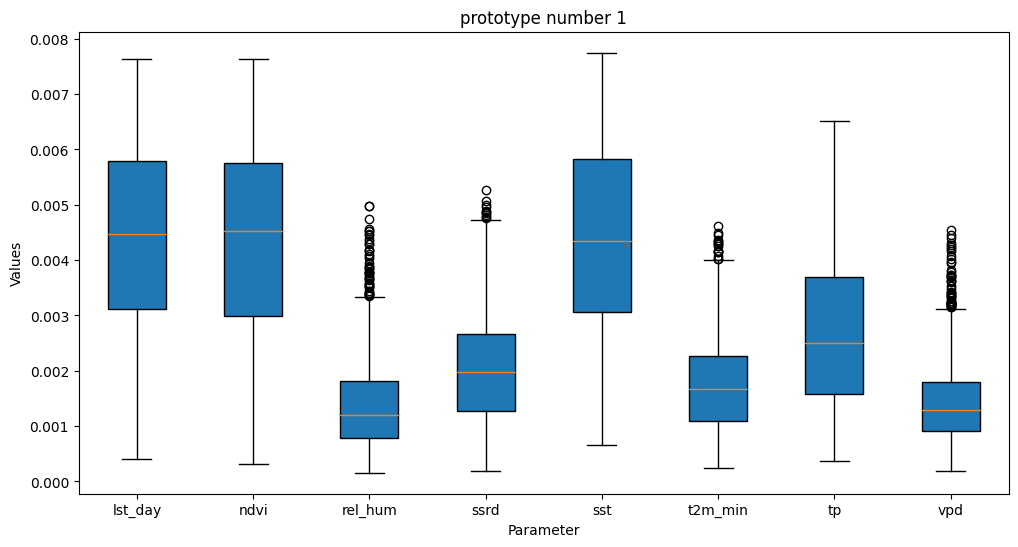

In [35]:
plot_all_boxplots(1)

In [22]:
EM = []
for i in range (10):
    proto = 10+i
    data = np.load(f'EM_proto/EMD_proto_{proto}.npy')
    EM.append(data)

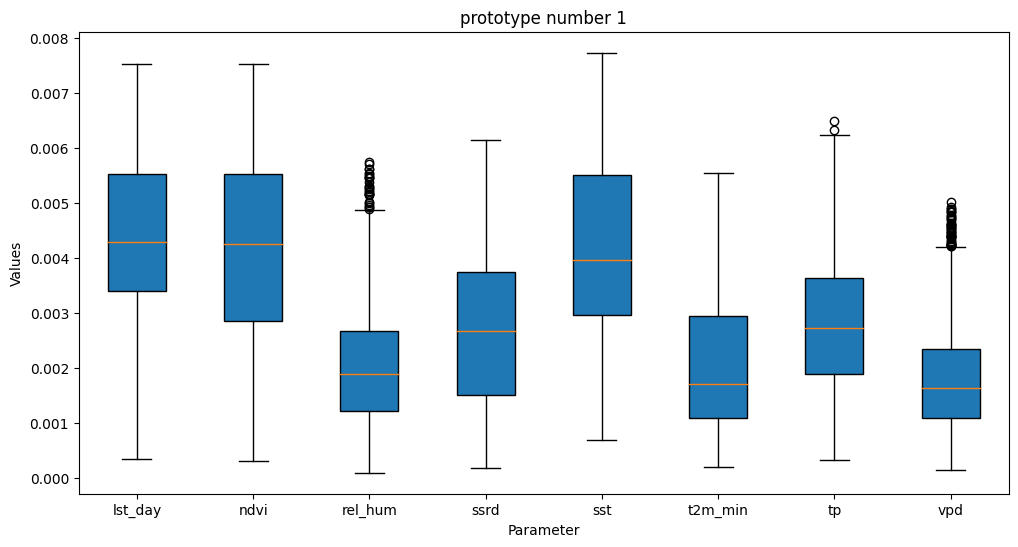

In [27]:
plot_all_boxplots(1)